# So sánh biên lợi nhuận theo năm

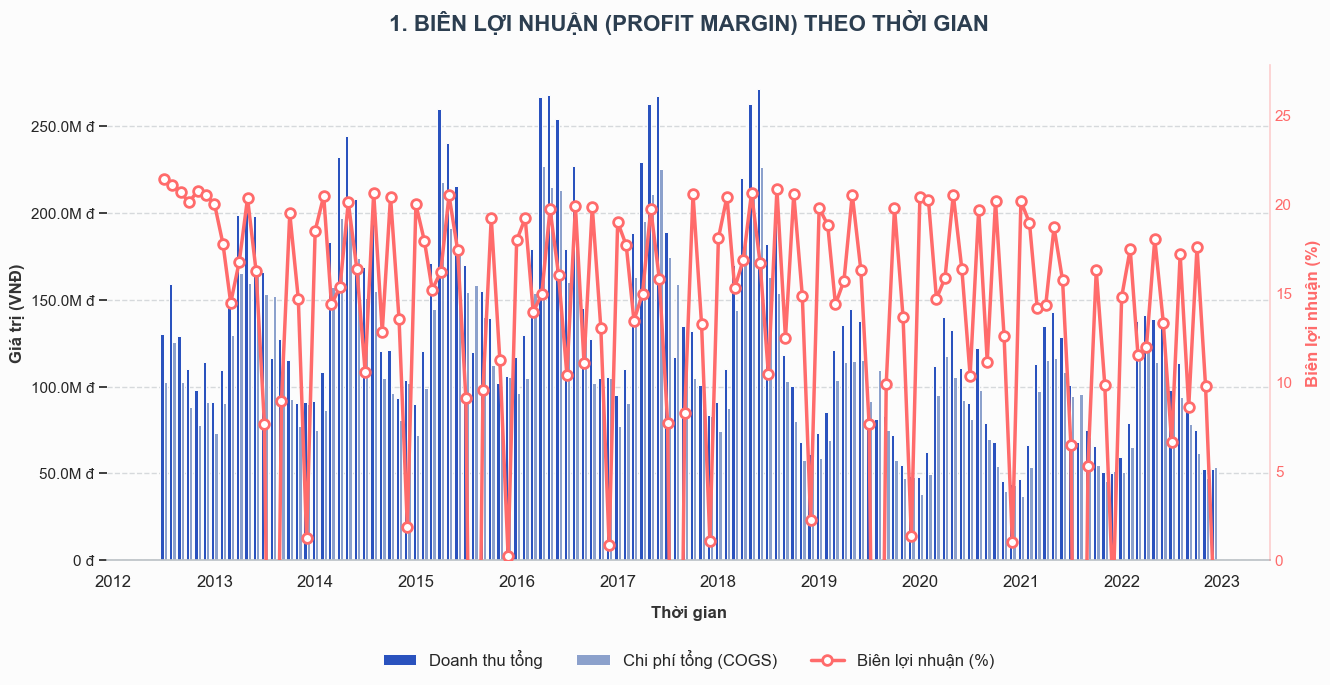

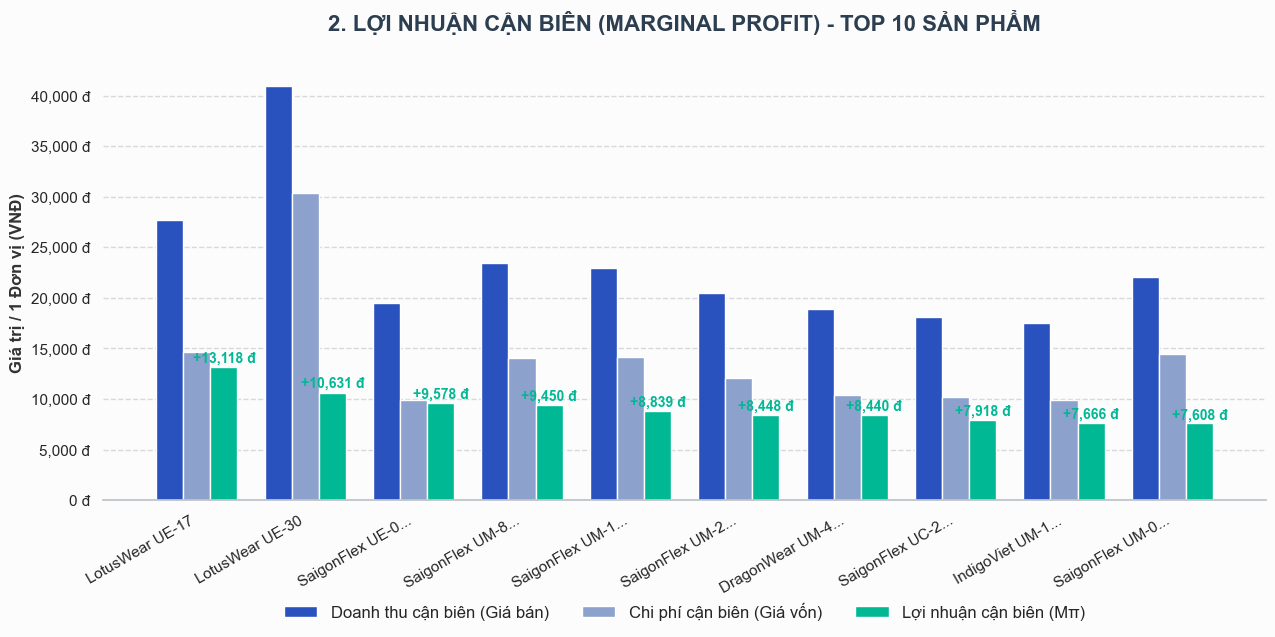

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

# ==========================================
# HÀM FORMAT TIỀN TỆ CHUNG (M/B ĐỒNG)
# ==========================================
def format_vnd_modern(val, pos):
    if val >= 1e9:
        return f"{val/1e9:.1f}B đ"
    elif val >= 1e6:
        return f"{val/1e6:.1f}M đ"
    else:
        return f"{val:,.0f} đ"

# Cài đặt giao diện chung
sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc", "figure.facecolor": "#fcfcfc"})

# ==============================================================================
# CHỦ ĐỀ 1: BIÊN LỢI NHUẬN (PROFIT MARGIN) - Đánh giá hiệu quả quản lý chi phí
# ==============================================================================
try:
    sales_df = pd.read_csv('../dataset/sales.csv')
    sales_df['Date'] = pd.to_datetime(sales_df['Date'])
    monthly_sales = sales_df.resample('MS', on='Date')[['Revenue', 'COGS']].sum().reset_index()
    
    monthly_sales['Gross_Profit'] = monthly_sales['Revenue'] - monthly_sales['COGS']
    monthly_sales['Profit_Margin_%'] = (monthly_sales['Gross_Profit'] / monthly_sales['Revenue']) * 100

    fig1, ax1 = plt.subplots(figsize=(15, 7.5))
    width = 12 
    x = monthly_sales['Date']

    color_revenue = '#2A52BE' # Xanh hoàng gia
    color_cogs = '#8CA1CC'    # Xanh nhạt
    color_margin = '#FF6B6B'  # Đỏ san hô

    ax1.bar(x - pd.Timedelta(days=6), monthly_sales['Revenue'], width=width, label='Doanh thu tổng', color=color_revenue, edgecolor='white', linewidth=0.7)
    ax1.bar(x + pd.Timedelta(days=6), monthly_sales['COGS'], width=width, label='Chi phí tổng (COGS)', color=color_cogs, edgecolor='white', linewidth=0.7)

    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(format_vnd_modern))
    ax1.set_ylabel('Giá trị (VNĐ)', fontsize=12, fontweight='bold', color='#333333')
    ax1.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
    ax1.set_axisbelow(True) 

    # Trục X timeline
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.tick_params(axis='x', which='major', labelsize=12, pad=10, length=0)
    ax1.xaxis.set_minor_locator(mdates.MonthLocator())
    ax1.tick_params(axis='x', which='minor', length=5, color='#bdc3c7', width=1.5) 
    ax1.set_xlabel('Thời gian', fontsize=12, fontweight='bold', labelpad=12, color='#333333')

    # Dọn dẹp viền
    for spine in ['top', 'right', 'left']:
        ax1.spines[spine].set_visible(False)
    ax1.spines['bottom'].set_color('#bdc3c7')

    # Đường Profit Margin
    ax2 = ax1.twinx()
    ax2.plot(x, monthly_sales['Profit_Margin_%'], color=color_margin, marker='o', 
             mfc='white', mec=color_margin, mew=2, linewidth=2.5, markersize=7, 
             label='Biên lợi nhuận (%)')
    ax2.set_ylabel('Biên lợi nhuận (%)', fontsize=12, fontweight='bold', color=color_margin, labelpad=10)
    ax2.tick_params(axis='y', labelcolor=color_margin, length=0)
    ax2.grid(False)
    for spine in ['top', 'left', 'bottom']:
        ax2.spines[spine].set_visible(False)
    ax2.spines['right'].set_color(color_margin)
    ax2.spines['right'].set_alpha(0.3)
    ax2.set_ylim(0, monthly_sales['Profit_Margin_%'].max() * 1.3) 

    # Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=12)

    plt.title('BIÊN LỢI NHUẬN (PROFIT MARGIN) THEO THỜI GIAN', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.22)
    plt.show()

except FileNotFoundError:
    print("Không tìm thấy file ../dataset/sales.csv")


# ==============================================================================
# CHỦ ĐỀ 2: LỢI NHUẬN CẬN BIÊN (MARGINAL PROFIT) - Quyết định sản lượng/sản phẩm
# ==============================================================================
try:
    products_df = pd.read_csv('../dataset/products.csv')
    
    # Tính Lợi nhuận cận biên (Mπ = Giá bán - Giá vốn)
    products_df['Marginal_Profit'] = products_df['price'] - products_df['cogs']
    
    # Lấy top 10 sản phẩm có lợi nhuận cận biên cao nhất để biểu diễn
    top_products = products_df.sort_values(by='Marginal_Profit', ascending=False).head(10)

    fig2, ax3 = plt.subplots(figsize=(15, 7.5))
    x_prod = np.arange(len(top_products))
    width_prod = 0.25

    color_price = '#2A52BE' # Xanh hoàng gia (MR)
    color_cost = '#8CA1CC'  # Xanh nhạt (MC)
    color_mp = '#00b894'    # Xanh lá (Lợi nhuận cận biên)

    ax3.bar(x_prod - width_prod, top_products['price'], width_prod, label='Doanh thu cận biên (Giá bán)', color=color_price, edgecolor='white')
    ax3.bar(x_prod, top_products['cogs'], width_prod, label='Chi phí cận biên (Giá vốn)', color=color_cost, edgecolor='white')
    ax3.bar(x_prod + width_prod, top_products['Marginal_Profit'], width_prod, label='Lợi nhuận cận biên (Mπ)', color=color_mp, edgecolor='white')

    ax3.yaxis.set_major_formatter(ticker.FuncFormatter(format_vnd_modern))
    ax3.set_ylabel('Giá trị / 1 Đơn vị (VNĐ)', fontsize=12, fontweight='bold', color='#333333')
    ax3.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
    ax3.set_axisbelow(True)

    # Rút gọn tên sản phẩm dài
    short_names = [str(name)[:15] + '...' if len(str(name)) > 15 else str(name) for name in top_products['product_name']]
    ax3.set_xticks(x_prod)
    ax3.set_xticklabels(short_names, rotation=30, ha='right', fontsize=11)
    
    # Dọn dẹp viền
    for spine in ['top', 'right', 'left']:
        ax3.spines[spine].set_visible(False)
    ax3.spines['bottom'].set_color('#bdc3c7')

    # Gắn nhãn giá trị lợi nhuận trực tiếp lên cột
    for i, val in enumerate(top_products['Marginal_Profit']):
        formatted_val = format_vnd_modern(val, None)
        ax3.text(i + width_prod, val + (val * 0.02), f'+{formatted_val}', ha='center', va='bottom', fontweight='bold', color=color_mp, fontsize=10)

    ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=12)

    plt.title('LỢI NHUẬN CẬN BIÊN (MARGINAL PROFIT) - TOP 10 SẢN PHẨM', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.3)
    plt.show()

except FileNotFoundError:
    print("Không tìm thấy file ../dataset/products.csv")

# Tính lợi nhuận biên theo category overtime

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_78173/4209990477.py:28: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('../dataset/order_items.csv')


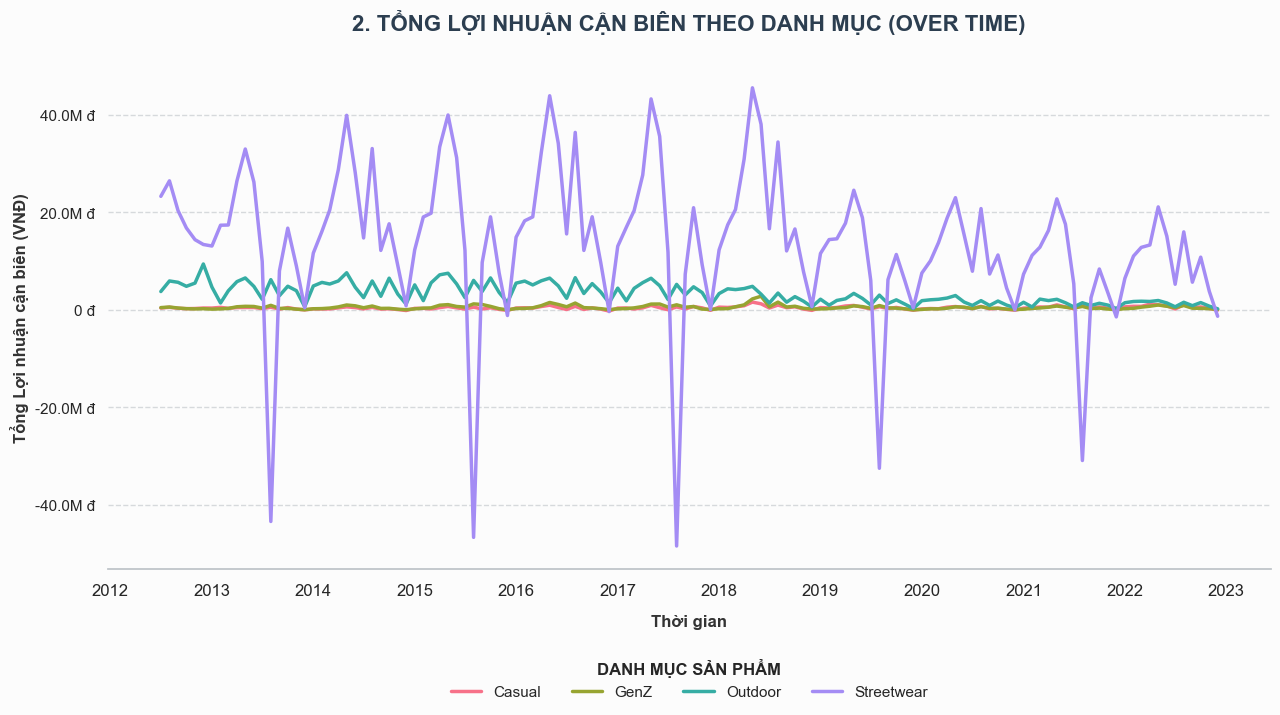

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

# ==========================================
# CẬP NHẬT HÀM FORMAT TIỀN TỆ (Xử lý cả số Âm)
# ==========================================
def format_vnd_modern(val, pos):
    abs_val = abs(val)
    sign = "-" if val < 0 else ""
    
    if abs_val >= 1e9:
        return f"{sign}{abs_val/1e9:.1f}B đ"
    elif abs_val >= 1e6:
        return f"{sign}{abs_val/1e6:.1f}M đ"
    else:
        return f"{val:,.0f} đ"

# Cài đặt giao diện
sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc", "figure.facecolor": "#fcfcfc"})

try:
    # ĐỌC VÀ KẾT NỐI DỮ LIỆU
    orders = pd.read_csv('../dataset/orders.csv')
    order_items = pd.read_csv('../dataset/order_items.csv')
    products = pd.read_csv('../dataset/products.csv')

    orders['order_date'] = pd.to_datetime(orders['order_date'])
    orders['Month_Start'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()

    df_items = pd.merge(order_items, products[['product_id', 'category', 'cogs']], on='product_id', how='left')
    df_items['Total_Marginal_Profit'] = (df_items['unit_price'] - df_items['cogs']) * df_items['quantity']
    df_full = pd.merge(df_items, orders[['order_id', 'Month_Start']], on='order_id', how='inner')

    profit_by_cat = df_full.groupby(['Month_Start', 'category'])['Total_Marginal_Profit'].sum().reset_index()
    pivot_df = profit_by_cat.pivot(index='Month_Start', columns='category', values='Total_Marginal_Profit').fillna(0)

    # VẼ BIỂU ĐỒ ĐƯỜNG
    fig, ax = plt.subplots(figsize=(15, 8))
    colors = sns.color_palette("husl", len(pivot_df.columns))
    
    # ==========================================
    # ĐÃ LOẠI BỎ THAM SỐ MARKER ĐỂ XÓA DẤU CHẤM
    # ==========================================
    for idx, col in enumerate(pivot_df.columns):
        ax.plot(pivot_df.index, pivot_df[col], linewidth=2.5, 
                label=col, color=colors[idx])

    # Cấu hình trục Y
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_vnd_modern))
    ax.set_ylabel('Tổng Lợi nhuận cận biên (VNĐ)', fontsize=12, fontweight='bold', color='#333333')
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
    ax.set_axisbelow(True)

    # Cấu hình trục X
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', which='major', labelsize=12, pad=10, length=0)
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', which='minor', length=5, color='#bdc3c7', width=1.5) 
    ax.set_xlabel('Thời gian', fontsize=12, fontweight='bold', labelpad=12, color='#333333')

    # Dọn dẹp viền
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#bdc3c7')

    # Legend
    ax.legend(title='DANH MỤC SẢN PHẨM', loc='upper center', bbox_to_anchor=(0.5, -0.15), 
              ncol=min(5, len(pivot_df.columns)), frameon=False, fontsize=11, 
              title_fontproperties={'weight':'bold'})

    plt.title('TỔNG LỢI NHUẬN CẬN BIÊN THEO DANH MỤC (OVER TIME)', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.25)
    plt.show()

except FileNotFoundError as e:
    print(f"Lỗi: Không tìm thấy file dữ liệu - {e}")

# Lợi nhuận biên theo năm và theo category

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_78173/3844312493.py:13: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('../dataset/order_items.csv')


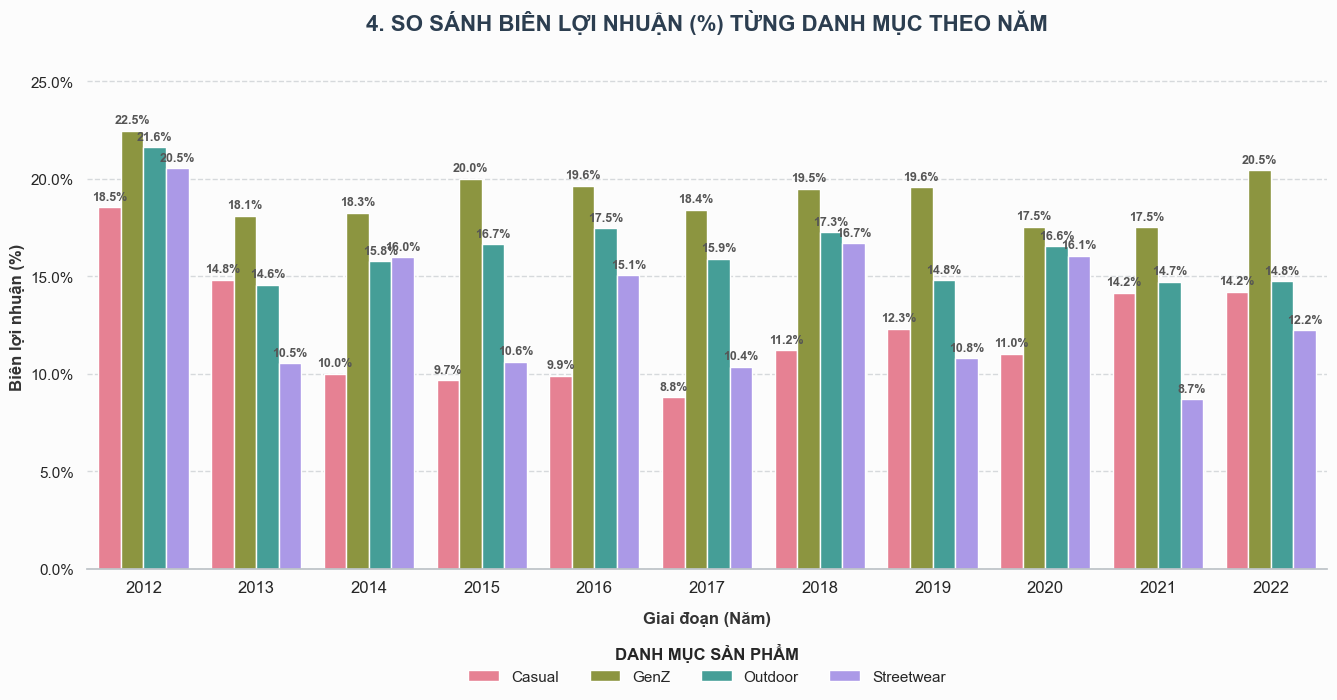

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Cài đặt giao diện tối giản, hiện đại
sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc", "figure.facecolor": "#fcfcfc"})

try:
    # 1. ĐỌC VÀ KẾT NỐI DỮ LIỆU
    orders = pd.read_csv('../dataset/orders.csv')
    order_items = pd.read_csv('../dataset/order_items.csv')
    products = pd.read_csv('../dataset/products.csv')

    orders['order_date'] = pd.to_datetime(orders['order_date'])
    orders['Year'] = orders['order_date'].dt.year

    # Kết nối dữ liệu để lấy Giá bán, Số lượng và Giá vốn
    df_items = pd.merge(order_items, products[['product_id', 'category', 'cogs']], on='product_id', how='left')
    
    # Tính Doanh thu và Giá vốn cho TỪNG DÒNG (Line item)
    df_items['Revenue'] = df_items['unit_price'] * df_items['quantity']
    df_items['Total_COGS'] = df_items['cogs'] * df_items['quantity']
    
    # Ghép bảng để lấy Năm (Year)
    df_full = pd.merge(df_items, orders[['order_id', 'Year']], on='order_id', how='inner')

    # 2. GỘP NHÓM THEO NĂM & DANH MỤC (Tính TỔNG trước)
    annual_cat_profit = df_full.groupby(['Year', 'category'])[['Revenue', 'Total_COGS']].sum().reset_index()

    # 3. TÍNH BIÊN LỢI NHUẬN (%) TỔNG THỂ
    annual_cat_profit['Profit_Margin_%'] = ((annual_cat_profit['Revenue'] - annual_cat_profit['Total_COGS']) / annual_cat_profit['Revenue']) * 100

    # 4. VẼ BIỂU ĐỒ CỘT PHÂN CỤM (GROUPED BAR CHART)
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Dùng Seaborn barplot để tự động nhóm cột (hue)
    sns.barplot(data=annual_cat_profit, 
                x='Year', 
                y='Profit_Margin_%', 
                hue='category', 
                palette='husl', 
                edgecolor='white',
                linewidth=1,
                ax=ax)

    # Cấu hình trục Y (Định dạng Phần trăm)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=1)) # Hiển thị 1 chữ số thập phân (VD: 25.5%)
    ax.set_ylabel('Biên lợi nhuận (%)', fontsize=12, fontweight='bold', color='#333333')
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
    ax.set_axisbelow(True)

    # Cấu hình trục X
    ax.set_xlabel('Giai đoạn (Năm)', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
    ax.tick_params(axis='x', labelsize=12, pad=8, length=0)

    # Dọn dẹp viền biểu đồ
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#bdc3c7')

    # Gắn nhãn giá trị (%) trực tiếp lên đầu mỗi cột để dễ đọc
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9, color='#555555', fontweight='bold')

    # Xử lý Legend (Gom xuống dưới cùng)
    ax.legend(title='DANH MỤC SẢN PHẨM', loc='upper center', bbox_to_anchor=(0.5, -0.12), 
              ncol=min(5, len(annual_cat_profit['category'].unique())), frameon=False, fontsize=11, 
              title_fontproperties={'weight':'bold'})

    # Mở rộng trần trục Y thêm 15% để số liệu trên đầu cột không bị cắt mất
    ymax = annual_cat_profit['Profit_Margin_%'].max()
    ax.set_ylim(0, ymax * 1.15)

    plt.title('SO SÁNH BIÊN LỢI NHUẬN (%) TỪNG DANH MỤC THEO NĂM', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.25)
    
    plt.show()

except FileNotFoundError as e:
    print(f"Lỗi: Không tìm thấy file dữ liệu - {e}")

# Lợi nhuận cận biên theo năm và chia theo category

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_78173/3173894722.py:26: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('../dataset/order_items.csv')


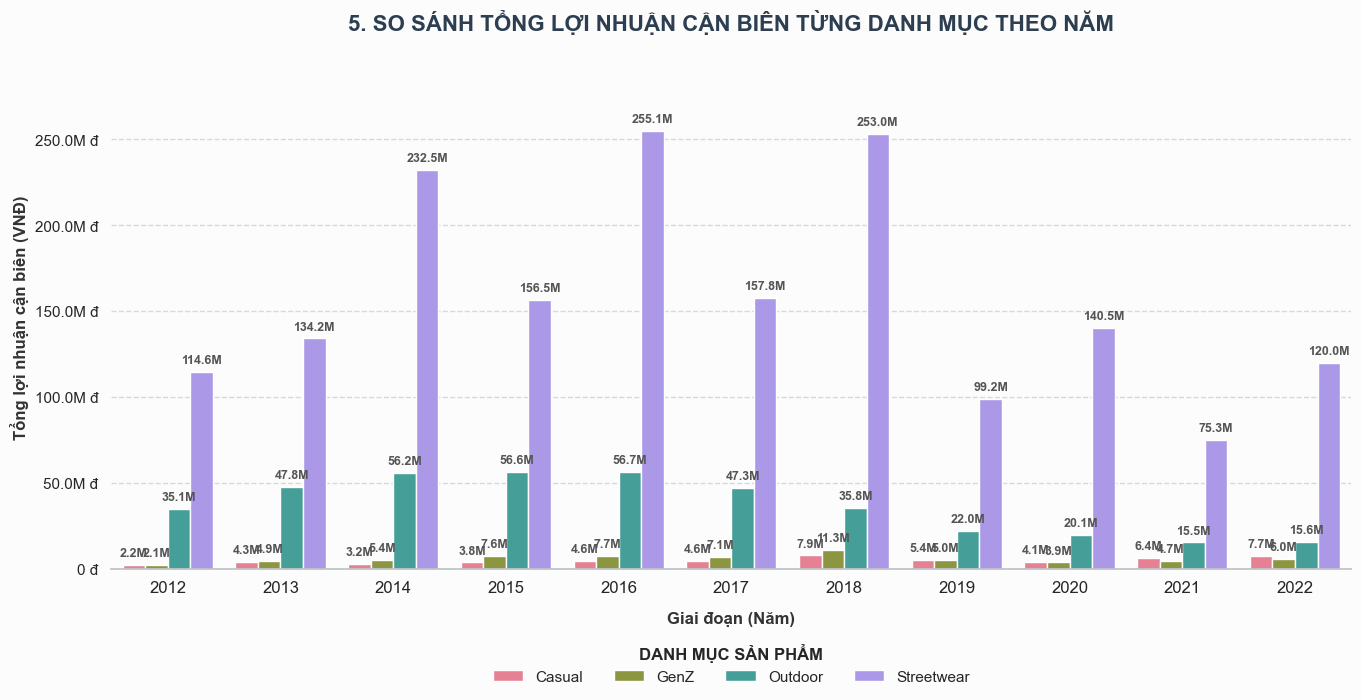

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ==========================================
# HÀM FORMAT TIỀN TỆ (Dùng cho Trục Y)
# ==========================================
def format_vnd_modern(val, pos=None):
    abs_val = abs(val)
    sign = "-" if val < 0 else ""
    if abs_val >= 1e9:
        return f"{sign}{abs_val/1e9:.1f}B đ"
    elif abs_val >= 1e6:
        return f"{sign}{abs_val/1e6:.1f}M đ"
    else:
        return f"{sign}{abs_val:,.0f} đ"

# Cài đặt giao diện tối giản
sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc", "figure.facecolor": "#fcfcfc"})

try:
    # 1. ĐỌC VÀ KẾT NỐI DỮ LIỆU
    orders = pd.read_csv('../dataset/orders.csv')
    order_items = pd.read_csv('../dataset/order_items.csv')
    products = pd.read_csv('../dataset/products.csv')

    orders['order_date'] = pd.to_datetime(orders['order_date'])
    orders['Year'] = orders['order_date'].dt.year

    # Kết nối dữ liệu
    df_items = pd.merge(order_items, products[['product_id', 'category', 'cogs']], on='product_id', how='left')
    
    # Tính Tổng Lợi nhuận cận biên cho từng dòng sản phẩm
    df_items['Total_Marginal_Profit'] = (df_items['unit_price'] - df_items['cogs']) * df_items['quantity']
    
    # Ghép bảng để lấy Năm (Year)
    df_full = pd.merge(df_items, orders[['order_id', 'Year']], on='order_id', how='inner')

    # 2. GỘP NHÓM TỔNG LỢI NHUẬN CẬN BIÊN THEO NĂM & DANH MỤC
    annual_cat_profit = df_full.groupby(['Year', 'category'])['Total_Marginal_Profit'].sum().reset_index()

    # 3. VẼ BIỂU ĐỒ CỘT PHÂN CỤM
    fig, ax = plt.subplots(figsize=(16, 8))
    
    sns.barplot(data=annual_cat_profit, 
                x='Year', 
                y='Total_Marginal_Profit', 
                hue='category', 
                palette='husl', 
                edgecolor='white',
                linewidth=1,
                ax=ax)

    # Cấu hình trục Y
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_vnd_modern))
    ax.set_ylabel('Tổng lợi nhuận cận biên (VNĐ)', fontsize=12, fontweight='bold', color='#333333')
    ax.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
    ax.set_axisbelow(True)

    # Cấu hình trục X
    ax.set_xlabel('Giai đoạn (Năm)', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
    ax.tick_params(axis='x', labelsize=12, pad=8, length=0)

    # Dọn dẹp viền biểu đồ
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#bdc3c7')

    # ==========================================
    # GẮN NHÃN RÚT GỌN (M/B) LÊN ĐỈNH CỘT
    # ==========================================
    for container in ax.containers:
        # Lấy giá trị của từng cột, bỏ qua nếu cột có giá trị 0 hoặc NaN
        labels = [format_vnd_modern(v.get_height()).replace(" đ", "") if v.get_height() != 0 else "" for v in container]
        ax.bar_label(container, labels=labels, padding=4, fontsize=9, color='#555555', fontweight='bold')

    # Xử lý Legend
    ax.legend(title='DANH MỤC SẢN PHẨM', loc='upper center', bbox_to_anchor=(0.5, -0.12), 
              ncol=min(5, len(annual_cat_profit['category'].unique())), frameon=False, fontsize=11, 
              title_fontproperties={'weight':'bold'})

    # Mở rộng trần trục Y thêm 15% để số liệu trên đầu cột không bị cắt mất
    ymax = annual_cat_profit['Total_Marginal_Profit'].max()
    ax.set_ylim(0, ymax * 1.15)

    plt.title('SO SÁNH TỔNG LỢI NHUẬN CẬN BIÊN TỪNG DANH MỤC THEO NĂM', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.25)
    
    plt.show()

except FileNotFoundError as e:
    print(f"Lỗi: Không tìm thấy file dữ liệu - {e}")